# Set up

In [54]:
# imports

from calendar import month_name
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sdmetrics.single_column import CategoryCoverage, KSComplement, RangeCoverage, TVComplement

In [55]:
# paths and columns

BASE_DIR = Path("")
LOCATION_GROUP = 3

CATEGORICAL_COLS = ["plugin_hour", "plugout_hour"]
NUMERICAL_COLS = ["connection_time", "energy_session"]
ALL_COLS = CATEGORICAL_COLS + NUMERICAL_COLS

# Helpers

In [56]:
# preprocessing real and fake data

def filter_invalid_sessions(df):
    valid = (df["connection_time"] > 0) & (df["energy_session"] > 0)
    valid = valid & (df["connection_time"] <= 120) & (df["energy_session"] <= 150)
    return df[valid].copy()


def add_time_features(df, plugin_time):
    df = df.copy()
    df["plugin_time"] = plugin_time
    df = df.dropna(subset=["plugin_time"])
    df["plugout_time"] = df["plugin_time"] + pd.to_timedelta(df["connection_time"], unit="h")

    df["plugin_hour"] = df["plugin_time"].dt.hour
    df["plugout_hour"] = df["plugout_time"].dt.hour
    df["month"] = df["plugin_time"].dt.month
    df["month_name"] = df["month"].map(lambda x: month_name[x])
    return df


def format_real_data(df):
    df = df.dropna(subset=["plugin_day", "plugin_month", "plugin_hour"]).copy()
    plugin_time = pd.to_datetime({
        "year": 2025,
        "month": df["plugin_month"],
        "day": df["plugin_day"],
        "hour": df["plugin_hour"],
    }, errors="coerce")
    return add_time_features(df, plugin_time)


def format_synthetic_data(df):
    df = df.dropna(subset=["__date__", "plugin_hour"]).copy()
    base_time = pd.to_datetime(df["__date__"]) + pd.to_timedelta(df["plugin_hour"], unit="h")
    perturb = pd.to_timedelta(np.random.randint(-30, 31, size=len(df)), unit="m")
    return add_time_features(df, base_time + perturb)


def load_synthetic_data(model_type):
    model_dir = BASE_DIR / model_type / "synthetic"
    data = {}
    for file in sorted(model_dir.glob("*.csv")):
        data[file.stem] = filter_invalid_sessions(pd.read_csv(file))
    return data


In [57]:
# evaluation metrics

def compute_distribution_metrics(real, synthetic, var_type):
    real = real.dropna()
    synthetic = synthetic.dropna()

    if len(real) == 0 or len(synthetic) == 0:
        return {m: np.nan for m in ["TVComplement", "JensenShannon", "KSComplement", "Wasserstein"]}

    if var_type == "categorical":
        real_probs = real.value_counts(normalize=True).sort_index()
        synth_probs = synthetic.value_counts(normalize=True).sort_index()
        all_cats = sorted(set(real_probs.index) | set(synth_probs.index))

        real_probs = real_probs.reindex(all_cats, fill_value=0)
        synth_probs = synth_probs.reindex(all_cats, fill_value=0)
        return {
            "TVComplement": TVComplement.compute(real, synthetic),
            "JensenShannon": jensenshannon(real_probs.values, synth_probs.values),
        }

    return {
        "KSComplement": KSComplement.compute(real, synthetic),
        "Wasserstein": wasserstein_distance(real, synthetic),
    }


def compute_coverage(real, synthetic, var_type):
    if var_type == "categorical":
        all_cats = sorted(set(real.dropna().unique()) | set(synthetic.dropna().unique()))
        real_cat = real.astype("category").cat.set_categories(all_cats)
        synth_cat = synthetic.astype("category").cat.set_categories(all_cats)
        return CategoryCoverage.compute(real_cat, synth_cat)
    return RangeCoverage.compute(real, synthetic)


def compute_correlation_similarity(real_df, synth_df):
    def get_association_matrix(df):
        df = df.copy()
        for col in CATEGORICAL_COLS:
            if col in df.columns:
                df[col] = df[col].astype("category")

        return associations(df[ALL_COLS], nominal_columns=CATEGORICAL_COLS,
                            numerical_columns=NUMERICAL_COLS, compute_only=True,
                            plot=False)["corr"]

    real_corr = get_association_matrix(real_df)
    synth_corr = get_association_matrix(synth_df)
    synth_corr = synth_corr.loc[real_corr.index, real_corr.columns]
    return np.linalg.norm(real_corr - synth_corr)


def calculate_model_score(metrics):
    weights = {
        "plugin_hour_TVComplement": 1/3,
        "connection_time_KSComplement": 1/3,
        "energy_session_KSComplement": 1/3,
    }

    score = 0
    for metric, weight in weights.items():
        score += metrics.get(metric, 0) * weight
    return score


In [58]:
def plot_panel_distribution_comparison(real_df, synth_df, columns, bins=30):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    metrics_report = []

    plt.rcParams.update({
        "axes.titlesize": 24,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 22,
    })

    for i, col in enumerate(columns):
        ax = axes[i]
        if col in CATEGORICAL_COLS:
            real_vals = real_df[col].value_counts(normalize=True).sort_index()
            synth_vals = synth_df[col].value_counts(normalize=True).sort_index()
            all_vals = sorted(set(real_vals.index) | set(synth_vals.index))

            real_vals = real_vals.reindex(all_vals, fill_value=0)
            synth_vals = synth_vals.reindex(all_vals, fill_value=0)
            tv = TVComplement.compute(real_df[col], synth_df[col])
            js = jensenshannon(real_vals.values, synth_vals.values)

            x = np.arange(len(all_vals))
            width = 0.35
            ax.bar(x - width/2, real_vals.values, width, alpha=0.7, label="Real", color="#1f77b4")
            ax.bar(x + width/2, synth_vals.values, width, alpha=0.7, label="Synthetic", color="#ff7f0e")
            ax.set_xticks(x)
            ax.set_xticklabels(all_vals, fontsize=16)
            ax.set_ylabel("Proportion")
            metrics_report.append(f"{col}: TVComplement={tv:.3f} | JSD={js:.3f}")
        else:
            ks = KSComplement.compute(real_df[col], synth_df[col])
            wd = wasserstein_distance(real_df[col], synth_df[col])

            ax.hist(real_df[col], bins=bins, alpha=0.5, label="Real", density=True, color="#1f77b4")
            ax.hist(synth_df[col], bins=bins, alpha=0.5, label="Synthetic", density=True, color="#ff7f0e")
            ax.set_ylabel("Density")
            metrics_report.append(f"{col}: KSComplement={ks:.3f} | Wasserstein={wd:.3f}")

        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_title(f"{col.replace('_', ' ').title()} Distribution")

    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2,
               bbox_to_anchor=(0.5, 1.02), fontsize=20, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



In [59]:
def evaluate_model(real_df, synth_df):
    synth_data = format_synthetic_data(synth_df)
    results = {"yearly_metrics": {}, "monthly_metrics": {}}

    yearly_metrics = {}
    for col in ALL_COLS:
        col_type = "categorical" if col in CATEGORICAL_COLS else "numerical"
        dist_metrics = compute_distribution_metrics(real_df[col], synth_data[col], col_type)
        for metric, value in dist_metrics.items():
            yearly_metrics[f"{col}_{metric}"] = value
        yearly_metrics[f"{col}_Coverage"] = compute_coverage(real_df[col], synth_data[col], col_type)

    yearly_metrics["CorrelationSimilarity"] = compute_correlation_similarity(real_df, synth_data)
    results["yearly_metrics"] = yearly_metrics

    for month in range(1, 13):
        month_label = month_name[month]
        month_real = real_df[real_df["month"] == month]
        month_synth = synth_data[synth_data["month"] == month]
        if month_real.empty or month_synth.empty:
            continue

        month_metrics = {}
        for col in ALL_COLS:
            col_type = "categorical" if col in CATEGORICAL_COLS else "numerical"
            dist_metrics = compute_distribution_metrics(month_real[col], month_synth[col], col_type)
            for metric, value in dist_metrics.items():
                month_metrics[f"{col}_{metric}"] = value
            month_metrics[f"{col}_Coverage"] = compute_coverage(month_real[col], month_synth[col], col_type)

        month_metrics["CorrelationSimilarity"] = compute_correlation_similarity(month_real, month_synth)
        results["monthly_metrics"][month_label] = month_metrics

    return results


def create_metrics_table(results):
    yearly_metrics = results["yearly_metrics"].copy()
    yearly_metrics["period"] = "Year"
    yearly_metrics["composite_score"] = calculate_model_score(results["yearly_metrics"])

    monthly_rows = []
    for month, metrics in results["monthly_metrics"].items():
        row = metrics.copy()
        row["period"] = month
        row["composite_score"] = calculate_model_score(metrics)
        monthly_rows.append(row)

    metrics_df = pd.DataFrame([yearly_metrics] + monthly_rows)
    columns_order = ["period", "composite_score"] + [
        col for col in metrics_df.columns if col not in ["period", "composite_score"]
    ]
    return metrics_df[columns_order]


# Evaluation

In [60]:
VAL_PATH = BASE_DIR / "diffusion/sets/val.csv"
TEST_PATH = BASE_DIR / "diffusion/sets/test.csv"

val_df = pd.read_csv(VAL_PATH).drop(columns="strata", errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns="strata", errors="ignore")

val_lg3 = filter_invalid_sessions(val_df[val_df["location_group"] == LOCATION_GROUP])
val_lg3 = format_real_data(val_lg3)

test_lg3 = filter_invalid_sessions(test_df[test_df["location_group"] == LOCATION_GROUP])
test_lg3 = format_real_data(test_lg3)

synthetic_models = {"Diffusion": load_synthetic_data("diffusion")}

if "synthetic_2025" in synthetic_models["Diffusion"]:
    synthetic_models["Diffusion"]["synthetic_2025"] = synthetic_models["Diffusion"]["synthetic_2025"].rename(
        columns={"date": "__date__"}
    )

combined_lg3 = pd.concat([val_lg3, test_lg3], ignore_index=True)

# Keep the original notebook behaviour: evaluate the final 2025 sample against val + test combined.
test_lg3 = combined_lg3.copy()

In [61]:
val_results = []

for model_type, models in synthetic_models.items():
    for model_name, synth_df in models.items():
        if model_name == "synthetic_2025":
            continue

        model_results = evaluate_model(val_lg3, synth_df)
        yearly_score = calculate_model_score(model_results["yearly_metrics"])
        monthly_scores = [calculate_model_score(m) for m in model_results["monthly_metrics"].values()]
        monthly_avg = np.mean(monthly_scores) if monthly_scores else 0
        overall_score = (yearly_score + monthly_avg) / 2

        val_results.append(
            {
                "model": model_type,
                "model_id": model_name,
                "yearly_score": yearly_score,
                "monthly_avg_score": monthly_avg,
                "overall_score": overall_score,
                **{f"yearly_{k}": v for k, v in model_results["yearly_metrics"].items()},
                **{
                    f"monthly_avg_{k}": np.mean(
                        [m.get(k, np.nan) for m in model_results["monthly_metrics"].values()]
                    )
                    for k in model_results["yearly_metrics"].keys()
                },
            }
        )

val_results_df = pd.DataFrame(val_results)
best_val_model = val_results_df.loc[val_results_df["overall_score"].idxmax()]

print(f"\nBest Validation Model: {best_val_model['model']} - {best_val_model['model_id']}")
print(f"Overall Score: {best_val_model['overall_score']:.4f}")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/yr/fk6c3f455rdf97sxlv2n6dtm0000gn/T/ipykernel_73632/3168968425.py", line 8, in <module>
    model_results = evaluate_model(val_lg3, synth_df)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/yr/fk6c3f455rdf97sxlv2n6dtm0000gn/T/ipykernel_73632/3489889198.py", line 13, in evaluate_model
    yearly_metrics["CorrelationSimilarity"] = compute_correlation_similarity(real_df, synth_data)
                                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/yr/fk6c3f455rdf97sxlv2n6dtm0000gn/T/ipykernel_73632/466005865.py", line 48, in compute_correlation_similarity
    real_corr = get_association_matrix(real_df)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/yr/fk6c3f455rdf97sxlv2n

In [ ]:
val_results_df

,model,model_id,yearly_score,monthly_avg_score,overall_score,yearly_plugin_hour_TVComplement,yearly_plugin_hour_JensenShannon,yearly_plugin_hour_Coverage,yearly_plugout_hour_TVComplement,yearly_plugout_hour_JensenShannon,...,monthly_avg_plugout_hour_TVComplement,monthly_avg_plugout_hour_JensenShannon,monthly_avg_plugout_hour_Coverage,monthly_avg_connection_time_KSComplement,monthly_avg_connection_time_Wasserstein,monthly_avg_connection_time_Coverage,monthly_avg_energy_session_KSComplement,monthly_avg_energy_session_Wasserstein,monthly_avg_energy_session_Coverage,monthly_avg_CorrelationSimilarity
0,Diffusion,synthetic_location_3_d1_h2,0.839031,0.749509,0.794270,0.785344,0.204291,1.0,0.692556,0.301392,...,0.585603,0.409410,1.0,0.803898,6.121472,1.000000,0.813824,6.320739,0.999746,0.885427
1,Diffusion,synthetic_location_3_d1_h4,0.853478,0.768019,0.810749,0.808131,0.170416,1.0,0.654820,0.318088,...,0.547154,0.430024,1.0,0.806099,3.996453,0.996733,0.837187,2.613896,0.995587,0.910284
2,Diffusion,synthetic_location_3_d1_h8,0.899379,0.791977,0.845678,0.869520,0.146119,1.0,0.673114,0.306203,...,0.560730,0.418242,1.0,0.832178,3.700731,0.994426,0.870020,2.315850,0.999191,0.924888
3,Diffusion,synthetic_location_3_d1_hnone,0.428015,0.343615,0.385815,0.304141,0.551419,1.0,0.347764,0.538796,...,0.262378,0.618209,1.0,0.394240,33.922144,1.000000,0.393996,40.766041,1.000000,1.165393
4,Diffusion,synthetic_location_3_d2_h2,0.906656,0.791871,0.849264,0.866685,0.140634,1.0,0.701135,0.295041,...,0.577937,0.404694,1.0,0.831971,3.120603,0.999895,0.867230,2.753704,0.985837,0.905315
5,Diffusion,synthetic_location_3_d2_h4,0.905292,0.789922,0.847607,0.882993,0.131367,1.0,0.712726,0.280403,...,0.594001,0.396624,1.0,0.831991,3.968653,0.999980,0.855979,3.944293,0.999797,0.925336
6,Diffusion,synthetic_location_3_d2_h8,0.880386,0.777342,0.828864,0.877287,0.136187,1.0,0.717495,0.281737,...,0.597271,0.396247,1.0,0.769902,7.258230,0.999875,0.875983,2.387095,0.999459,0.859226
7,Diffusion,synthetic_location_3_d2_hnone,0.500448,0.363601,0.432025,0.331206,0.519995,1.0,0.406451,0.495434,...,0.325154,0.576250,1.0,0.464158,40.593857,1.000000,0.377407,33.416321,1.000000,1.159879
8,Diffusion,synthetic_location_3_d3_h2,0.926611,0.795774,0.861193,0.874301,0.129350,1.0,0.689326,0.302521,...,0.579242,0.409732,1.0,0.852841,3.052635,0.977662,0.852567,2.715700,0.991558,0.880522
9,Diffusion,synthetic_location_3_d3_h4,0.911913,0.791499,0.851706,0.906421,0.116301,1.0,0.679222,0.302437,...,0.574122,0.408740,1.0,0.824672,3.522491,0.944496,0.854716,2.775572,0.998411,0.850300


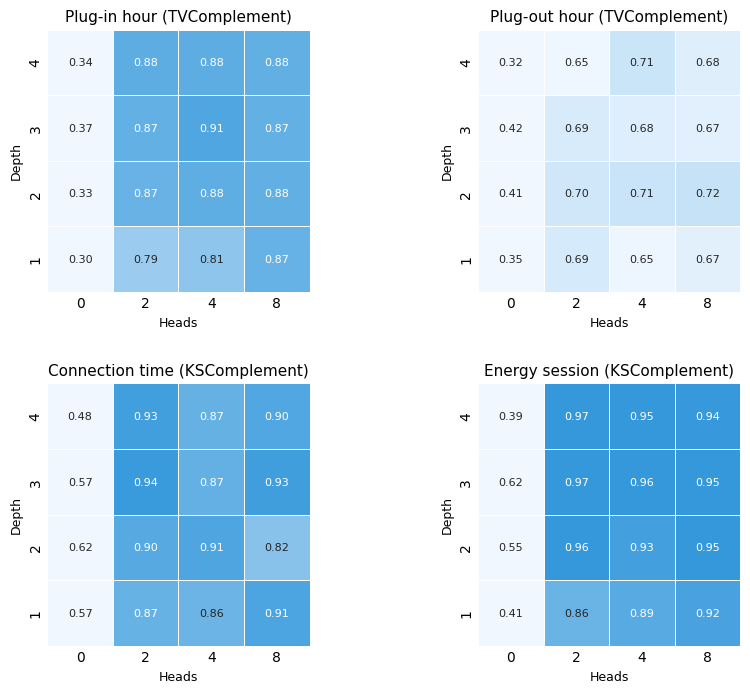

In [ ]:
val_results_df['Heads'] = val_results_df['model_id'].str.extract(r'_h(.+)$')[0].replace('none', '0').astype(int)
val_results_df['Depth'] = val_results_df['model_id'].str.extract(r'_d(\d)')[0].astype(int)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': False
})

cmap = LinearSegmentedColormap.from_list('minimal_blue', ['#f0f7ff', '#3498db'], N=256)

metrics = [
    ('yearly_plugin_hour_TVComplement', 'Plug-in hour (TVComplement)'),
    ('yearly_plugout_hour_TVComplement', 'Plug-out hour (TVComplement)'),
    ('yearly_connection_time_KSComplement', 'Connection time (KSComplement)'),
    ('yearly_energy_session_KSComplement', 'Energy session (KSComplement)')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (metric, title) in zip(axes.flat, metrics):
    heatmap_data = (
        val_results_df.pivot_table(
            index='Depth',
            columns='Heads',
            values=metric,
            aggfunc='first'
        ).sort_index(ascending=False)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        ax=ax,
        vmin=0.65,
        vmax=0.95
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Heads', fontsize=9)
    ax.set_ylabel('Depth', fontsize=9)
    ax.tick_params(axis='both', which='both', length=0)

fig.subplots_adjust(wspace=0.25, hspace=0.35)
plt.savefig('diff_validation_grid_heatmaps.png', dpi=300)
plt.show()


In [ ]:
synth_2025 = synthetic_models["Diffusion"]["synthetic_2025"]

test_results = evaluate_model(test_lg3, synth_2025)

yearly_score = calculate_model_score(test_results["yearly_metrics"])
monthly_scores = [calculate_model_score(m) for m in test_results["monthly_metrics"].values()]
monthly_avg = np.mean(monthly_scores) if monthly_scores else 0
overall_score = (yearly_score + monthly_avg) / 2

monthly_scores = {
    month: calculate_model_score(metrics)
    for month, metrics in test_results["monthly_metrics"].items()
}
best_month = max(monthly_scores, key=monthly_scores.get)
worst_month = min(monthly_scores, key=monthly_scores.get)

print("\nTest Set Performance for synthetic_2025:")
print(f"Yearly Score: {yearly_score:.4f}")
print(f"Average Monthly Score: {monthly_avg:.4f}")
print(f"Best Month: {best_month} ({monthly_scores[best_month]:.4f})")
print(f"Worst Month: {worst_month} ({monthly_scores[worst_month]:.4f})")


Test Set Performance for synthetic_2025:
Yearly Score: 0.9329
Average Monthly Score: 0.8348
Best Month: March (0.8741)
Worst Month: August (0.8008)



Yearly Distributions Comparison (Test Set):


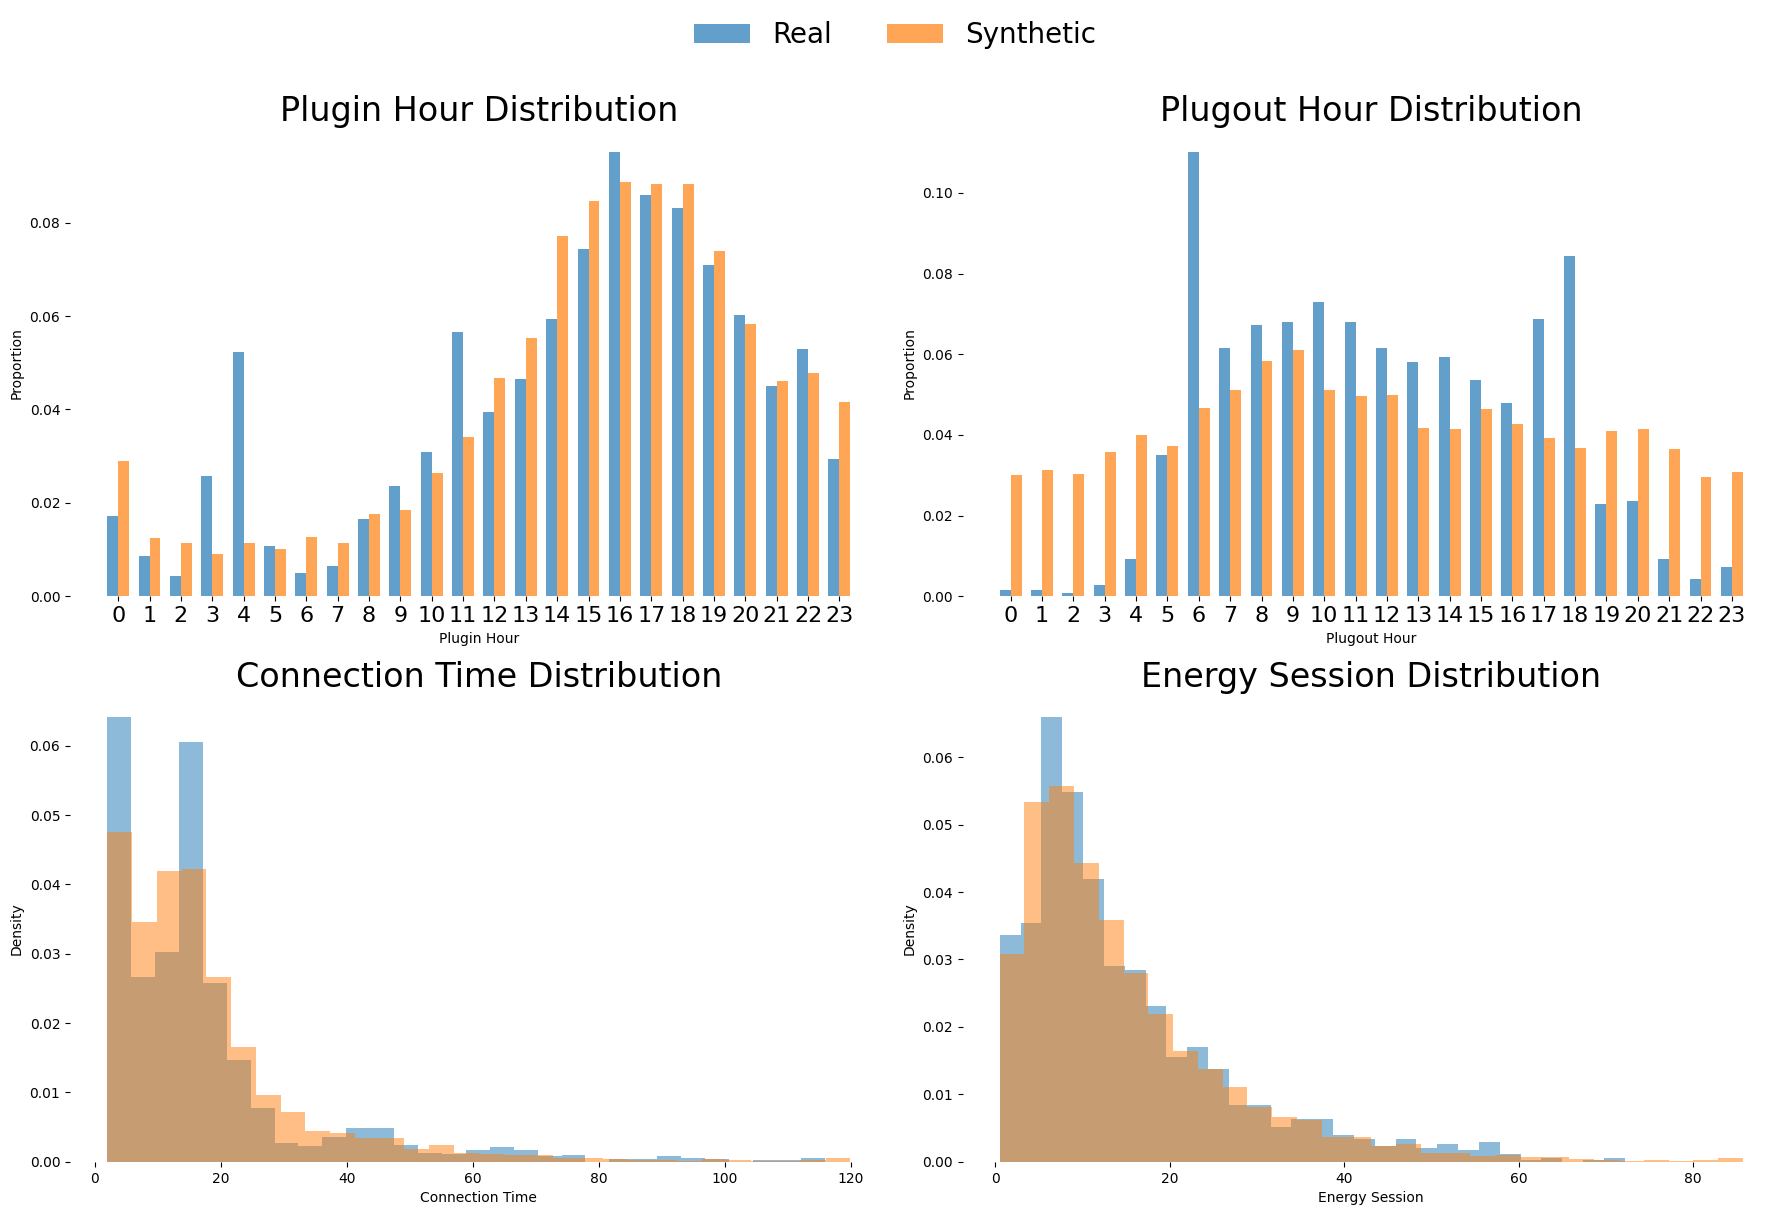


January Distributions (Best Month):


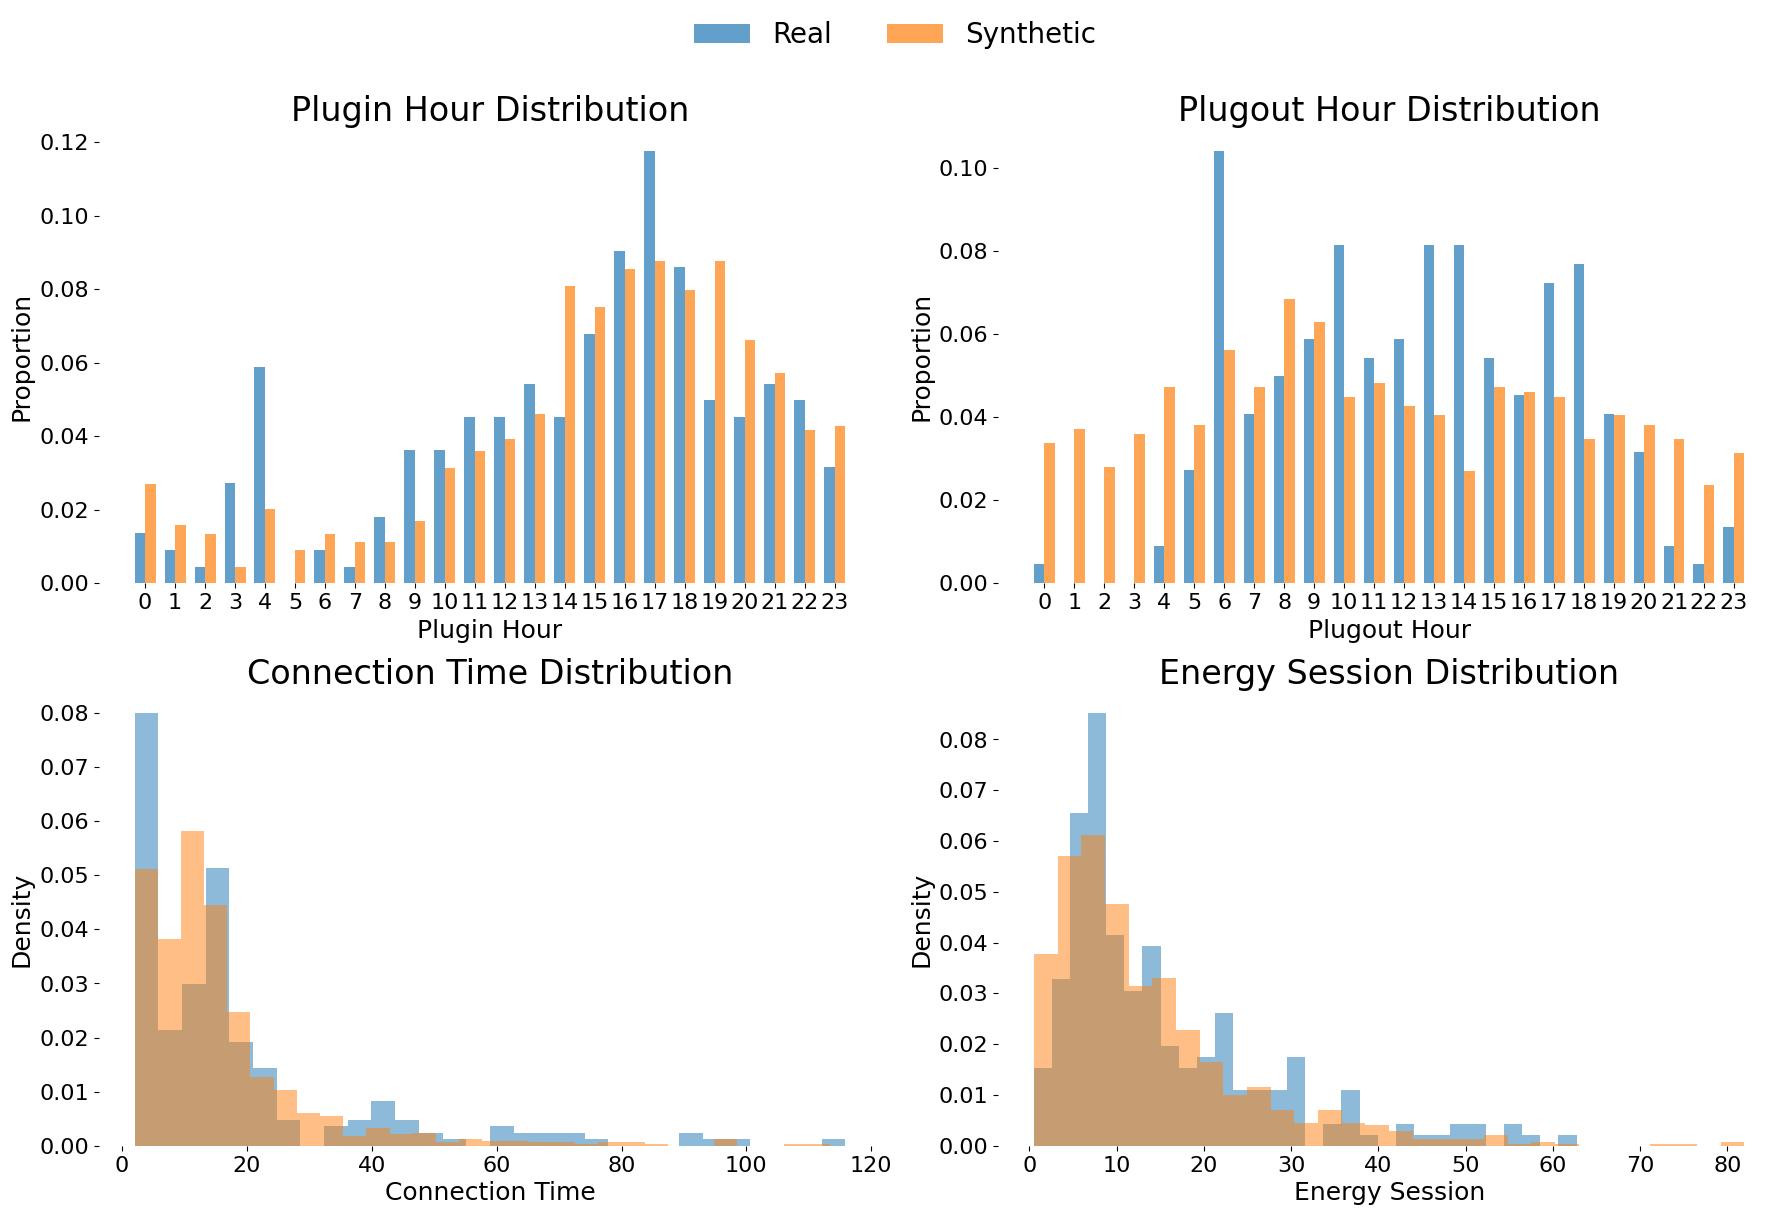


August Distributions (Worst Month):


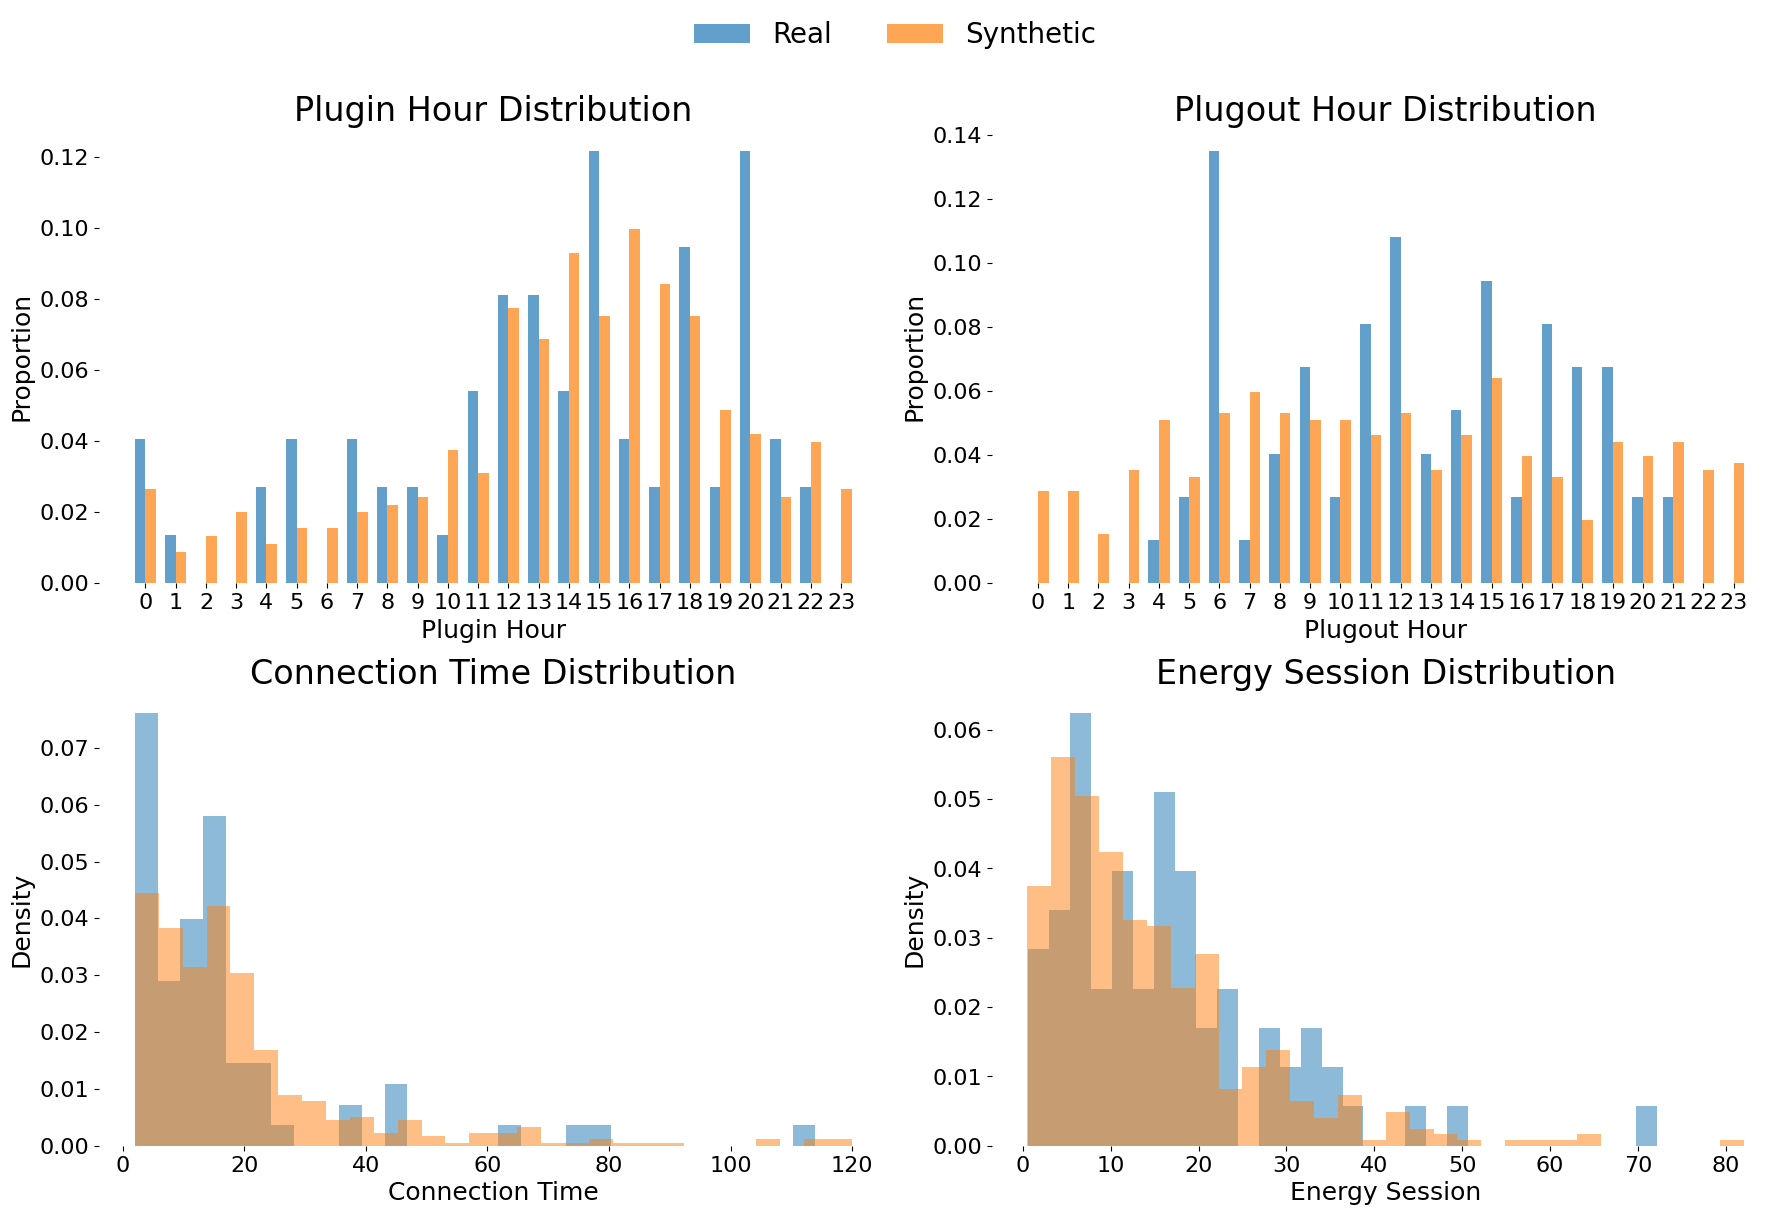

In [ ]:
synth_2025_formatted = format_synthetic_data(synth_2025)

print("\nYearly Distributions Comparison (Test Set):")
plot_panel_distribution_comparison(
    test_lg3,
    synth_2025_formatted,
    columns=ALL_COLS,
)

best_month_to_plot = "January"
print(f"\n{best_month_to_plot} Distributions (Best Month):")
plot_panel_distribution_comparison(
    test_lg3[test_lg3["month_name"] == best_month_to_plot],
    synth_2025_formatted[synth_2025_formatted["month_name"] == best_month_to_plot],
    columns=ALL_COLS,
)

print(f"\n{worst_month} Distributions (Worst Month):")
plot_panel_distribution_comparison(
    test_lg3[test_lg3["month_name"] == worst_month],
    synth_2025_formatted[synth_2025_formatted["month_name"] == worst_month],
    columns=ALL_COLS,
)

val_results_df.to_csv(BASE_DIR / "validation_results.csv", index=False)

test_results_df = pd.DataFrame(
    [
        {
            "model": "Diffusion",
            "model_id": "synthetic_2025",
            "yearly_score": yearly_score,
            "monthly_avg_score": monthly_avg,
            "overall_score": overall_score,
            **{f"yearly_{k}": v for k, v in test_results["yearly_metrics"].items()},
            **{
                f"monthly_avg_{k}": np.mean(
                    [m.get(k, np.nan) for m in test_results["monthly_metrics"].values()]
                )
                for k in test_results["yearly_metrics"].keys()
            },
        }
    ]
)
test_results_df.to_csv(BASE_DIR / "test_results_synthetic_2025.csv", index=False)

In [ ]:
test_metrics_table = create_metrics_table(test_results)
formatted_table = test_metrics_table.copy()

for col in formatted_table.columns:
    if col in ["period", "composite_score"]:
        continue

    if "Coverage" in col:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.0%}")
    elif "JensenShannon" in col or "Wasserstein" in col or "CorrelationSimilarity" in col:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.3f}")
    else:
        formatted_table[col] = formatted_table[col].apply(lambda x: f"{x:.4f}")

print("Performance Metrics for synthetic_2025 Model on Test Set")
display(formatted_table)

test_metrics_table.to_csv(BASE_DIR / "detailed_metrics_synthetic_2025.csv", index=False)
print("\nDetailed metrics saved to 'detailed_metrics_synthetic_2025.csv'")

Performance Metrics for synthetic_2025 Model on Test Set


,period,composite_score,plugin_hour_TVComplement,plugin_hour_JensenShannon,plugin_hour_Coverage,plugout_hour_TVComplement,plugout_hour_JensenShannon,plugout_hour_Coverage,connection_time_KSComplement,connection_time_Wasserstein,connection_time_Coverage,energy_session_KSComplement,energy_session_Wasserstein,energy_session_Coverage,CorrelationSimilarity
0,Year,0.932938,0.8904,0.124,100%,0.7313,0.270,100%,0.9359,1.321,100%,0.9725,0.530,100%,0.396
1,January,0.865968,0.8400,0.165,100%,0.7132,0.291,100%,0.8729,3.875,98%,0.8849,1.801,100%,0.450
2,February,0.834138,0.7602,0.262,100%,0.6787,0.328,100%,0.9074,2.615,100%,0.8348,3.635,100%,0.397
3,March,0.874142,0.8153,0.210,100%,0.7096,0.309,100%,0.9173,1.257,100%,0.8899,1.819,100%,0.684
4,April,0.819602,0.7408,0.255,100%,0.6392,0.367,100%,0.8431,4.503,100%,0.8749,2.831,100%,1.036
5,May,0.810072,0.6745,0.322,100%,0.5954,0.395,100%,0.8935,2.297,100%,0.8622,1.744,100%,0.966
6,June,0.816262,0.6830,0.302,100%,0.6272,0.366,100%,0.8819,3.749,100%,0.8838,1.768,100%,0.966
7,July,0.830358,0.7170,0.276,100%,0.6306,0.365,100%,0.8929,2.124,100%,0.8811,1.946,98%,1.184
8,August,0.800805,0.7300,0.276,100%,0.6423,0.356,100%,0.8123,3.161,100%,0.8601,2.121,100%,0.746
9,September,0.828139,0.7495,0.242,100%,0.6963,0.321,100%,0.8906,2.854,100%,0.8444,1.722,100%,0.892



Detailed metrics saved to 'detailed_metrics_synthetic_2025.csv'


In [ ]:
summary_cols = [
    "period",
    "composite_score",
    "plugin_hour_TVComplement",
    "plugin_hour_JensenShannon",
    "connection_time_KSComplement",
    "connection_time_Wasserstein",
    "energy_session_KSComplement",
    "energy_session_Wasserstein",
    "CorrelationSimilarity",
]

summary_table = test_metrics_table[summary_cols].copy()
summary_table_formatted = summary_table.copy()

for col in summary_table_formatted.columns[1:]:
    if "JensenShannon" in col or "Wasserstein" in col or "CorrelationSimilarity" in col:
        summary_table_formatted[col] = summary_table_formatted[col].apply(lambda x: f"{x:.3f}")
    else:
        summary_table_formatted[col] = summary_table_formatted[col].apply(lambda x: f"{x:.4f}")

print("Key Performance Metrics for synthetic_2025 Model")
display(summary_table_formatted)

summary_table.to_csv(BASE_DIR / "summary_metrics_synthetic_2025.csv", index=False)

Key Performance Metrics for synthetic_2025 Model


,period,composite_score,plugin_hour_TVComplement,plugin_hour_JensenShannon,connection_time_KSComplement,connection_time_Wasserstein,energy_session_KSComplement,energy_session_Wasserstein,CorrelationSimilarity
0,Year,0.9329,0.8904,0.124,0.9359,1.321,0.9725,0.530,0.396
1,January,0.8660,0.8400,0.165,0.8729,3.875,0.8849,1.801,0.450
2,February,0.8341,0.7602,0.262,0.9074,2.615,0.8348,3.635,0.397
3,March,0.8741,0.8153,0.210,0.9173,1.257,0.8899,1.819,0.684
4,April,0.8196,0.7408,0.255,0.8431,4.503,0.8749,2.831,1.036
5,May,0.8101,0.6745,0.322,0.8935,2.297,0.8622,1.744,0.966
6,June,0.8163,0.6830,0.302,0.8819,3.749,0.8838,1.768,0.966
7,July,0.8304,0.7170,0.276,0.8929,2.124,0.8811,1.946,1.184
8,August,0.8008,0.7300,0.276,0.8123,3.161,0.8601,2.121,0.746
9,September,0.8281,0.7495,0.242,0.8906,2.854,0.8444,1.722,0.892


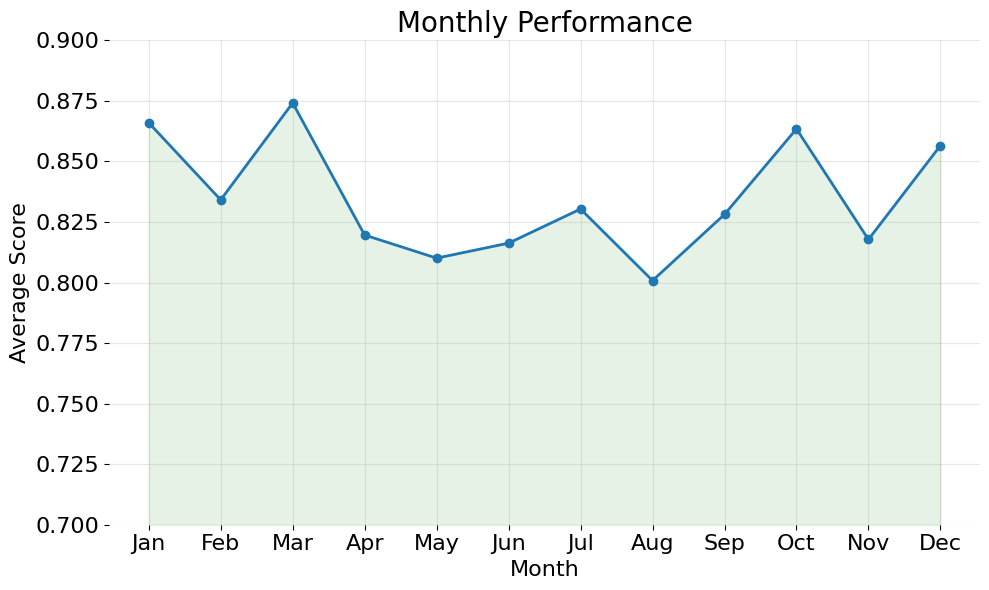

In [ ]:
plt.figure(figsize=(10, 6))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
scores = summary_table["composite_score"].iloc[1:13]

plt.plot(months, scores, marker="o", linestyle="-", color="#1f77b4", linewidth=2)
plt.fill_between(months, scores, 0.7, alpha=0.1, color="green")
plt.xlabel("Month", fontsize=16)
plt.ylabel("Average Score", fontsize=16)
plt.title("Monthly Performance", fontsize=20)
plt.ylim(0.7, 0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()